In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns
import itertools
import sys
from pathlib import Path

In [24]:
project_root = Path().resolve().parent
close_df = pd.read_csv(project_root / "data/close_relative_to_filing.csv")
eda_df = pd.read_csv(project_root / "data/eda_df.csv")
kmeans = pd.read_csv(project_root / "data/k_means_eda_df.csv")
X_train_feature_engin_cols = pd.read_csv(project_root / "data/cleaned_X_train.csv")
X_test_feature_engin_cols = pd.read_csv(project_root / "data/cleaned_X_test.csv")

In [25]:
cols = ['past_filings_per_person_eda',
        'high_price',
        'high_change_in_holdings',
        'is_large_trade',
        'is_large_trade_x_high_change_in_holdings']
        
X_train_feature_engin_cols = X_train_feature_engin_cols[cols]
X_test_feature_engin_cols = X_test_feature_engin_cols[cols]
feature_engin_cols = pd.concat([X_train_feature_engin_cols, X_test_feature_engin_cols])
feature_engin_cols

,past_filings_per_person_eda,high_price,high_change_in_holdings,is_large_trade,is_large_trade_x_high_change_in_holdings
0,0,True,False,False,False
1,1,True,True,False,False
2,2,True,False,False,False
3,3,True,True,False,False
4,4,True,True,False,False
...,...,...,...,...,...
61963,48,True,False,False,False
61964,48,True,False,False,False
61965,40,True,True,False,False
61966,7,True,True,False,False


In [ ]:
eda_df = eda_df.join([kmeans,feature_engin_cols], how="left")
eda_df.columns

,issuer.tradingSymbol,reportingOwner.name,transactionDate,amounts.shares,amounts.pricePerShare,reportingOwner.relationship.isDirector,reportingOwner.relationship.isOfficer,reportingOwner.relationship.isTenPercentOwner,holding_change_percent,direct_ownership,...,target_9,target_10,target_20,target_60,kmeans,past_filings_per_person_eda,high_price,high_change_in_holdings,is_large_trade,is_large_trade_x_high_change_in_holdings
0,BDC,Biegacki Steven,2008-10-14,30,25.50,False,True,False,0.000000,False,...,False,False,False,False,0,0.0,True,False,False,False
0,BDC,Biegacki Steven,2008-10-14,30,25.50,False,True,False,0.000000,False,...,False,False,False,False,0,0.0,False,False,False,False
1,BDC,Biegacki Steven,2008-10-15,100,23.19,False,True,False,76.923080,False,...,False,False,False,False,2,1.0,True,True,False,False
1,BDC,Biegacki Steven,2008-10-15,100,23.19,False,True,False,76.923080,False,...,False,False,False,False,2,1.0,False,False,False,False
2,BDC,Biegacki Steven,2008-10-22,200,22.75,False,True,False,0.000000,False,...,False,False,False,False,0,2.0,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
237034,ED,Donnley Deneen L,2023-12-29,42,90.97,False,True,False,0.506557,True,...,False,False,False,False,0,NaN,NaN,NaN,NaN,NaN
237035,ED,HOGLUND ROBERT N,2023-12-29,150,90.97,False,True,False,0.336518,True,...,False,False,False,False,0,NaN,NaN,NaN,NaN,NaN
237036,ED,Miller Joseph,2023-12-29,12,90.97,False,True,False,1.068222,True,...,False,False,False,False,0,NaN,NaN,NaN,NaN,NaN
237037,SPG,Roe Peggy Fang,2023-12-29,49,143.85,True,False,False,1.289134,True,...,False,False,False,False,0,NaN,NaN,NaN,NaN,NaN


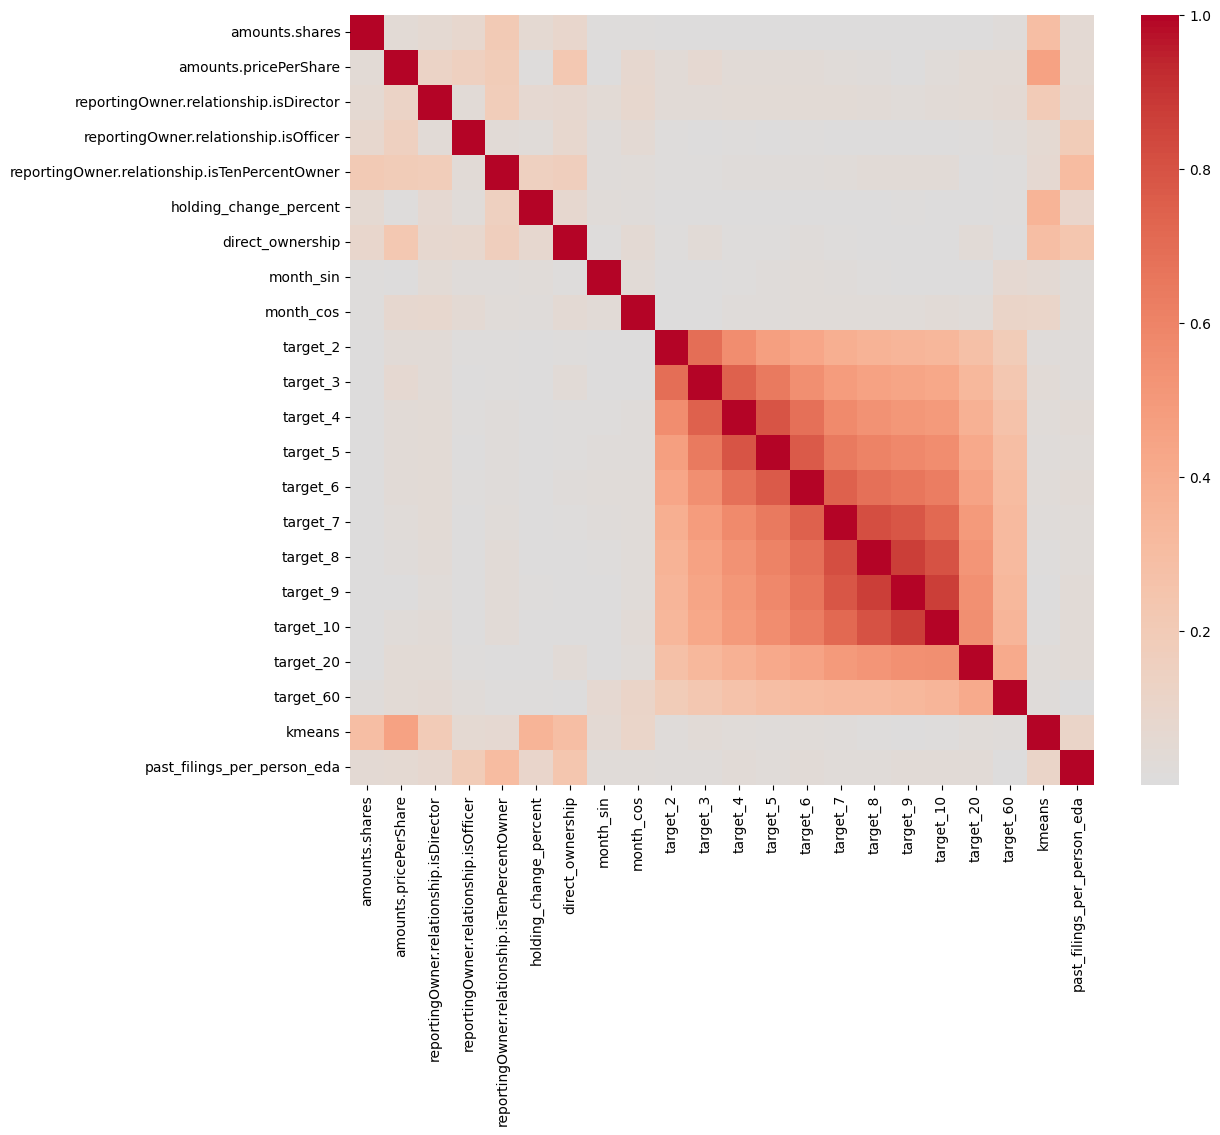

In [28]:
project_root = Path().resolve().parent
sys.path.append(str(project_root / "src/02_data_preperation"))

from data_cleaning_helper import plot_heatmap
plot_heatmap(eda_df.select_dtypes(include=["integer", "float", "bool"]))

C:\Users\tsymb\AppData\Local\Temp\ipykernel_8936\1752810857.py:20: RuntimeWarning: Mean of empty slice
  row_mean = np.nanmean(abs_mat, axis=1, keepdims=True)


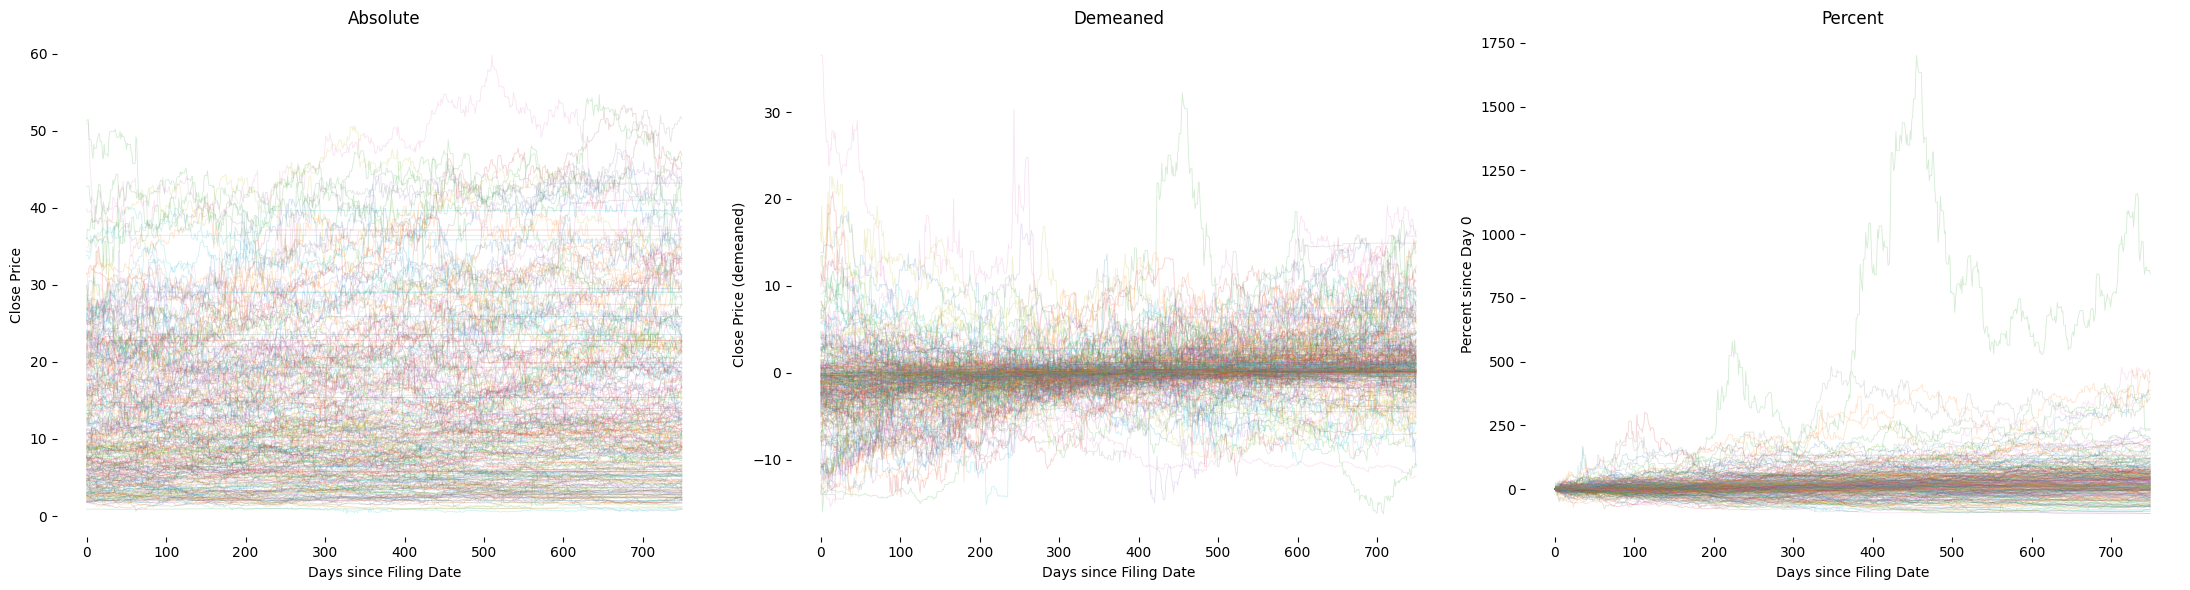

In [3]:
day_cols = [str(i) for i in range(750)]

df_numeric = close_df[day_cols]
Q1 = df_numeric.quantile(0.25)
Q3 = df_numeric.quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

mask = ~((df_numeric < lower) | (df_numeric > upper)).any(axis=1)
df_numeric = df_numeric[mask]

# data is to large, plot only a n=300 sample
sample = df_numeric.sample(n=300, random_state=69)

# with matrix else warning
abs_mat = sample[day_cols].to_numpy(dtype=float)

row_mean = np.nanmean(abs_mat, axis=1, keepdims=True)
demean_mat = abs_mat - row_mean

ref = sample[day_cols[0]].to_numpy(dtype=float)[:, None]
ref = np.where(ref == 0, np.nan, ref)
percent_mat = ((abs_mat - ref) / ref)*100

x = np.arange(750)

fig, axs = plt.subplots(1, 3, figsize=(22, 6), sharex=True)

axs[0].plot(x, abs_mat.T, linewidth=0.6, alpha=0.2)
axs[0].set_title('Absolute')
axs[0].set_xlabel('Days since Filing Date')
axs[0].set_ylabel('Close Price')

axs[1].plot(x, demean_mat.T, linewidth=0.6, alpha=0.2)
axs[1].set_title('Demeaned')
axs[1].set_xlabel('Days since Filing Date')
axs[1].set_ylabel('Close Price (demeaned)')

axs[2].plot(x, percent_mat.T, linewidth=0.6, alpha=0.2)
axs[2].set_title('Percent')
axs[2].set_xlabel('Days since Filing Date')
axs[2].set_ylabel('Percent since Day 0')

for ax in axs:
    for spine in ax.spines.values():
        spine.set_visible(False)

plt.tight_layout()
plt.savefig(project_root/ 'exports/close_random_300.png', dpi=500)
plt.show()

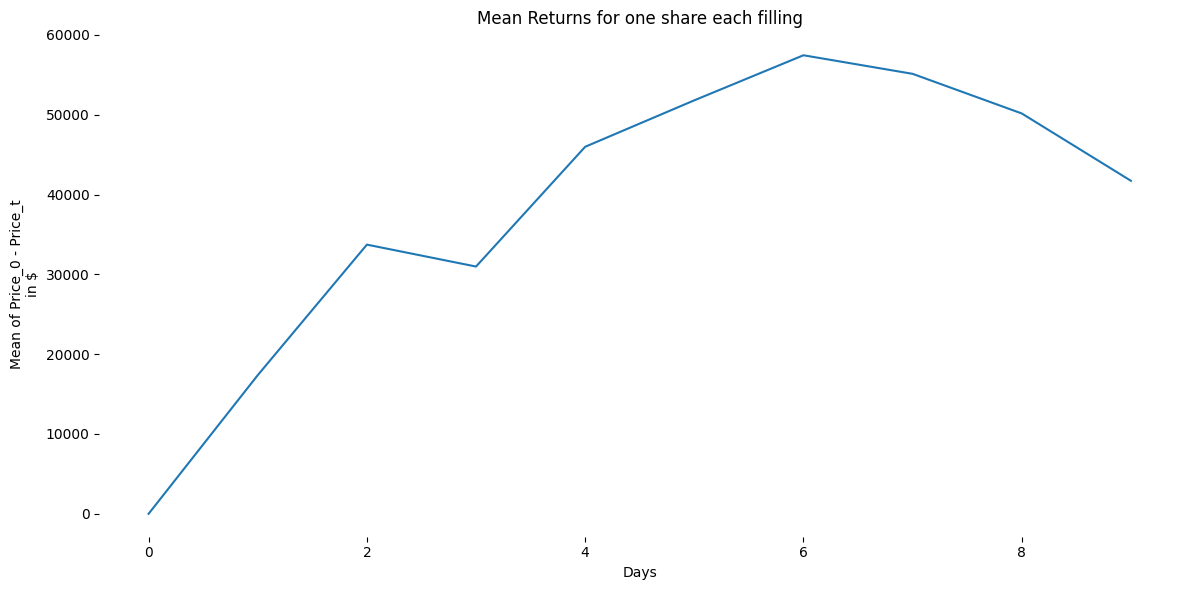

In [4]:
x_0 = close_df['0'].to_numpy()[:, None]
day_cols = [str(i) for i in range(10)]
Xt = close_df[day_cols].to_numpy()
return_matrix = Xt - x_0
return_df = pd.DataFrame(return_matrix)
mean_return = return_df.mean()

fig, ax = plt.subplots(1, 1, figsize=(12, 6))

ax.plot(mean_return)
ax.set_title('Mean Returns for one share each filling')
ax.set_xlabel('Days')
ax.set_ylabel('Mean of Price_0 - Price_t\nin $')
ax.ticklabel_format(style='plain', axis='y')
for s in ax.spines.values():
    s.set_visible(False)

plt.tight_layout()
plt.savefig(project_root / 'exports/mean_return_10d.png', dpi=500)
plt.show()

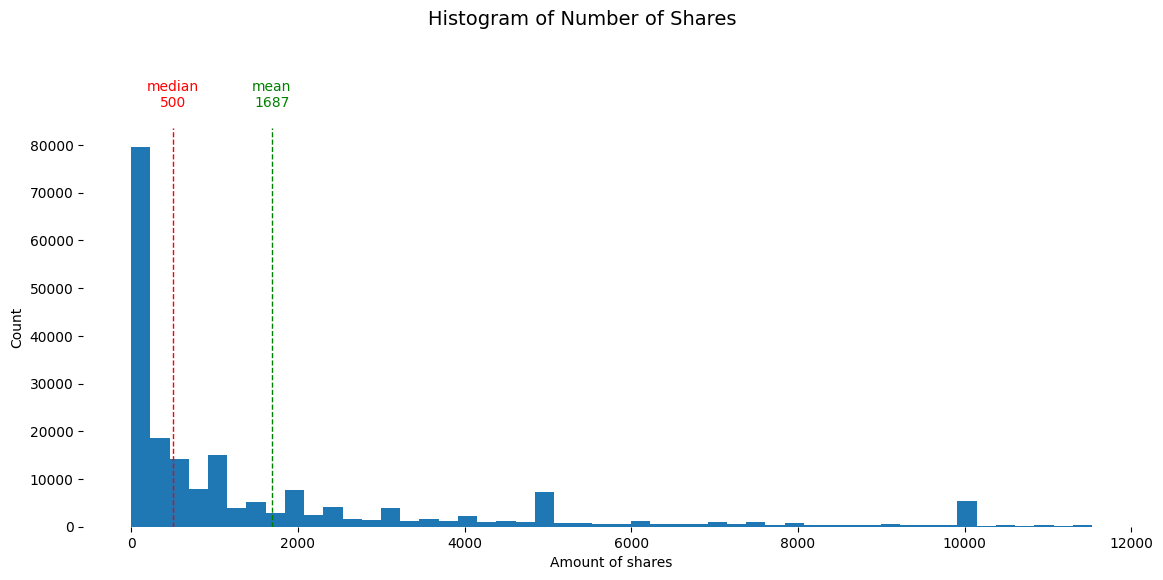

In [11]:
shares = eda_df["amounts.shares"]
Q1 = shares.quantile(0.25)
Q3 = shares.quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

mask = (shares >= lower) & (shares <= upper)
shares = shares[mask]

fig, ax = plt.subplots(1, 1, figsize=(12, 6))
fig.suptitle("Histogram of Number of Shares", fontsize=14)
ax.hist(shares, bins=50)
ax.set_xlabel('Amount of shares')
ax.set_ylabel('Count')

median = shares.median()

for s in ax.spines.values():
    s.set_visible(False)
ax.axvline(median, linestyle="--", lw=1, c="red")
ax.text(median,
        ax.get_ylim()[1]*+1.12,
        f"median\n{median:.0f}",
        va="top",
        ha="center",
        color="red")

mean = shares.mean()

for s in ax.spines.values():
    s.set_visible(False)
ax.axvline(mean, linestyle="--", lw=1, c="green")
ax.text(mean,
        ax.get_ylim()[1]*+1.12,
        f"mean\n{mean:.0f}",
        va="top",
        ha="center",
        color="green")

plt.tight_layout(pad=2.0, w_pad=1.0, h_pad=2.0)
plt.savefig(project_root / 'exports/histogram_of_number_of_shares.png', dpi=500)
plt.show()

In [9]:
eda_df

,issuer.tradingSymbol,reportingOwner.name,transactionDate,amounts.shares,amounts.pricePerShare,reportingOwner.relationship.isDirector,reportingOwner.relationship.isOfficer,reportingOwner.relationship.isTenPercentOwner,holding_change_percent,direct_ownership,...,target_3,target_4,target_5,target_6,target_7,target_8,target_9,target_10,target_20,target_60
0,BDC,Biegacki Steven,2008-10-14,30,25.50,False,True,False,0.000000,False,...,False,False,False,False,False,False,False,False,False,False
1,BDC,Biegacki Steven,2008-10-15,100,23.19,False,True,False,76.923080,False,...,False,False,False,False,False,False,False,False,False,False
2,BDC,Biegacki Steven,2008-10-22,200,22.75,False,True,False,0.000000,False,...,False,False,False,False,False,False,False,False,False,False
3,BDC,Biegacki Steven,2008-10-22,100,21.50,False,True,False,50.000000,False,...,False,False,False,False,False,False,False,False,False,False
4,BDC,Biegacki Steven,2008-10-23,100,18.52,False,True,False,33.333332,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
237034,ED,Donnley Deneen L,2023-12-29,42,90.97,False,True,False,0.506557,True,...,False,False,False,False,False,False,False,False,False,False
237035,ED,HOGLUND ROBERT N,2023-12-29,150,90.97,False,True,False,0.336518,True,...,False,False,False,False,False,False,False,False,False,False
237036,ED,Miller Joseph,2023-12-29,12,90.97,False,True,False,1.068222,True,...,False,False,False,False,False,False,False,False,False,False
237037,SPG,Roe Peggy Fang,2023-12-29,49,143.85,True,False,False,1.289134,True,...,False,False,False,False,False,False,False,False,False,False


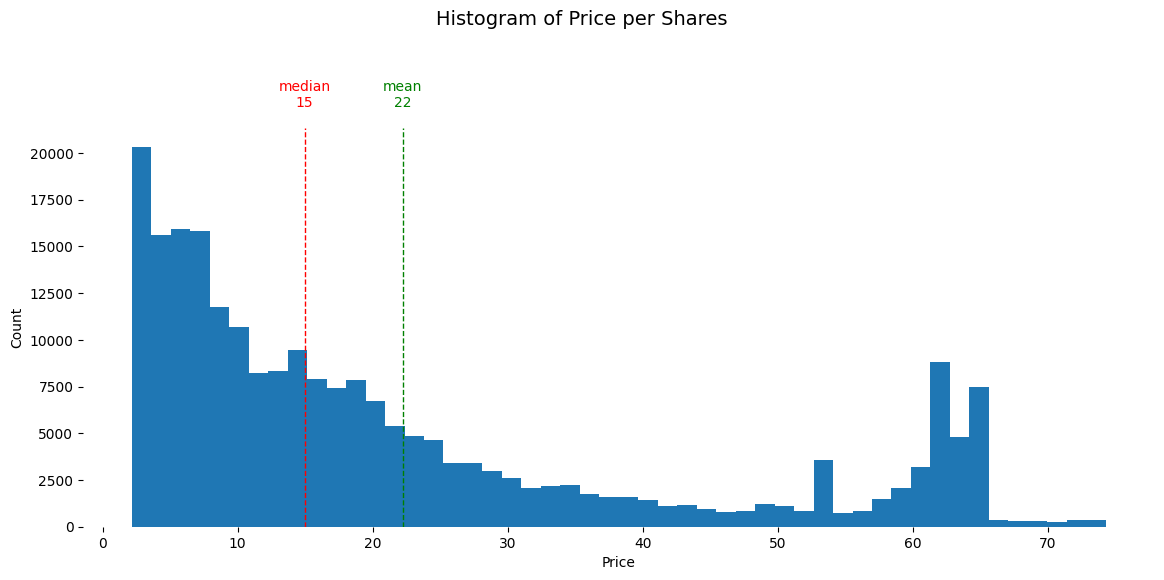

In [12]:
shares = eda_df["amounts.pricePerShare"]
Q1 = shares.quantile(0.25)
Q3 = shares.quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

mask = (shares >= lower) & (shares <= upper)
shares = shares[mask]

fig, ax = plt.subplots(1, 1, figsize=(12, 6))
fig.suptitle("Histogram of Price per Shares", fontsize=14)
ax.hist(shares, bins=50)
ax.set_xlabel('Price')
ax.set_ylabel('Count')

median = shares.median()

for s in ax.spines.values():
    s.set_visible(False)
ax.axvline(median, linestyle="--", lw=1, c="red")
ax.text(median,
        ax.get_ylim()[1]*+1.12,
        f"median\n{median:.0f}",
        va="top",
        ha="center",
        color="red")

mean = shares.mean()

for s in ax.spines.values():
    s.set_visible(False)
ax.axvline(mean, linestyle="--", lw=1, c="green")
ax.text(mean,
        ax.get_ylim()[1]*+1.12,
        f"mean\n{mean:.0f}",
        va="top",
        ha="center",
        color="green")

plt.tight_layout(pad=2.0, w_pad=1.0, h_pad=2.0)
plt.savefig(project_root / 'exports/histogram_of_amounts.pricePerShare.png', dpi=500)
plt.show()

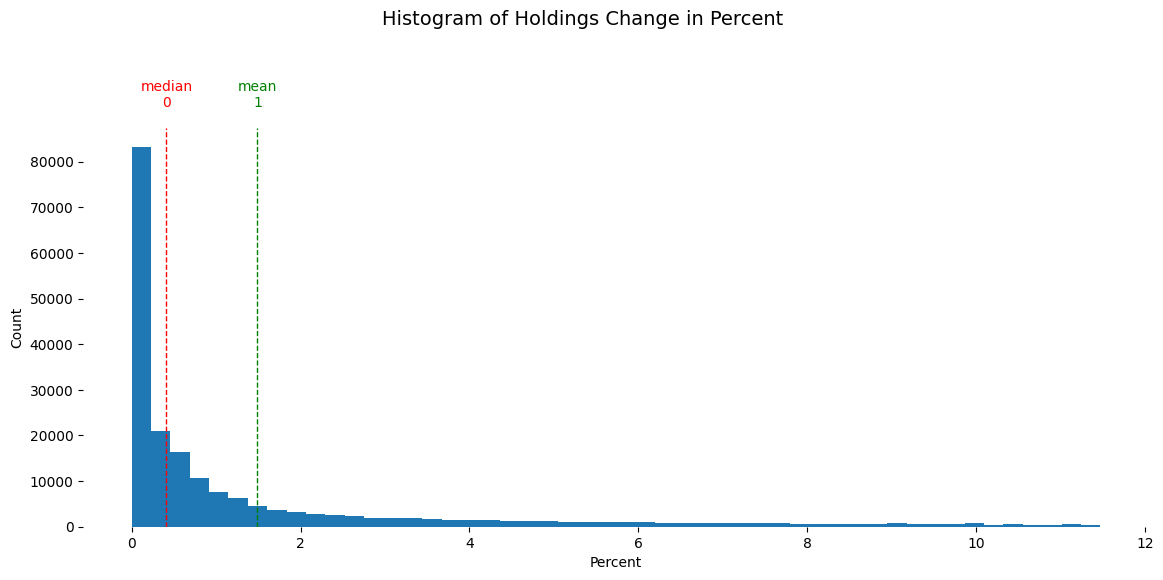

In [ ]:
shares = eda_df["holding_change_percent"]
Q1 = shares.quantile(0.25)
Q3 = shares.quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

mask = (shares >= lower) & (shares <= upper)
shares = shares[mask]

fig, ax = plt.subplots(1, 1, figsize=(12, 6))
fig.suptitle("Histogram of Holdings Change in Percent", fontsize=14)
ax.hist(shares, bins=50)
ax.set_xlabel('Percent')
ax.set_ylabel('Count')

median = shares.median()

for s in ax.spines.values():
    s.set_visible(False)
ax.axvline(median, linestyle="--", lw=1, c="red")
ax.text(median,
        ax.get_ylim()[1]*+1.12,
        f"median\n{median:.0f}",
        va="top",
        ha="center",
        color="red")

mean = shares.mean()

for s in ax.spines.values():
    s.set_visible(False)
ax.axvline(mean, linestyle="--", lw=1, c="green")
ax.text(mean,
        ax.get_ylim()[1]*+1.12,
        f"mean\n{mean:.0f}",
        va="top",
        ha="center",
        color="green")

plt.tight_layout(pad=2.0, w_pad=1.0, h_pad=2.0)
plt.savefig(project_root / 'exports/histogram_of_holding_change_percent.png', dpi=500)
plt.show()

In [29]:
eda_df.columns

Index(['issuer.tradingSymbol', 'reportingOwner.name', 'transactionDate',
       'amounts.shares', 'amounts.pricePerShare',
       'reportingOwner.relationship.isDirector',
       'reportingOwner.relationship.isOfficer',
       'reportingOwner.relationship.isTenPercentOwner',
       'holding_change_percent', 'direct_ownership', 'month_sin', 'month_cos',
       'target_2', 'target_3', 'target_4', 'target_5', 'target_6', 'target_7',
       'target_8', 'target_9', 'target_10', 'target_20', 'target_60', 'kmeans',
       'past_filings_per_person_eda', 'high_price', 'high_change_in_holdings',
       'is_large_trade', 'is_large_trade_x_high_change_in_holdings'],
      dtype='object')

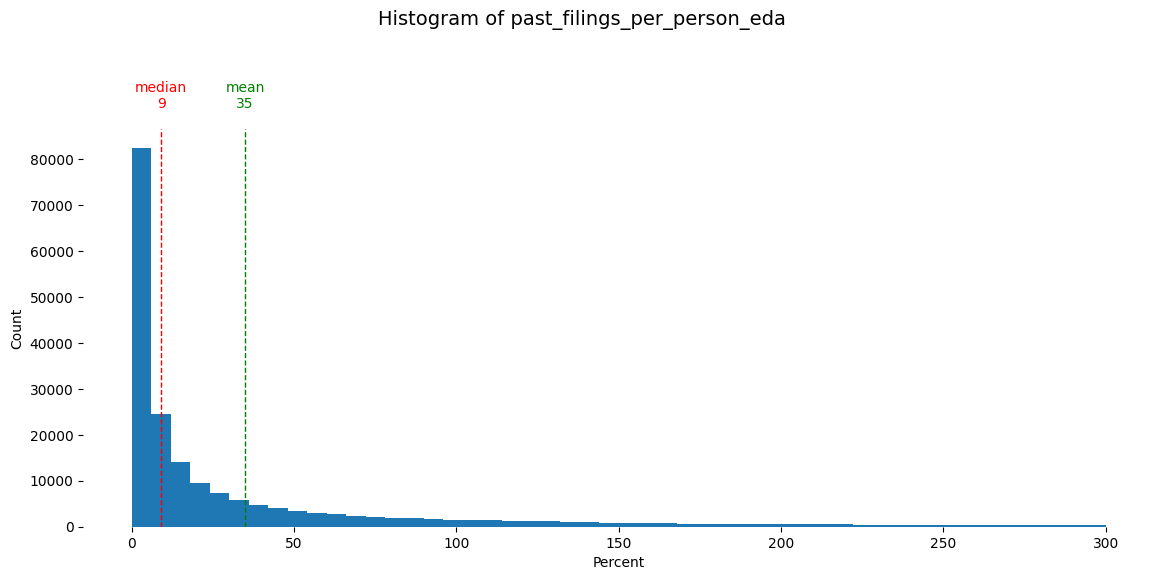

In [30]:
shares = eda_df["past_filings_per_person_eda"]
Q1 = shares.quantile(0.25)
Q3 = shares.quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

mask = (shares >= lower) & (shares <= upper)
shares = shares[mask]

fig, ax = plt.subplots(1, 1, figsize=(12, 6))
fig.suptitle("Histogram of past_filings_per_person_eda", fontsize=14)
ax.hist(shares, bins=50)
ax.set_xlabel('Percent')
ax.set_ylabel('Count')

median = shares.median()

for s in ax.spines.values():
    s.set_visible(False)
ax.axvline(median, linestyle="--", lw=1, c="red")
ax.text(median,
        ax.get_ylim()[1]*+1.12,
        f"median\n{median:.0f}",
        va="top",
        ha="center",
        color="red")

mean = shares.mean()

for s in ax.spines.values():
    s.set_visible(False)
ax.axvline(mean, linestyle="--", lw=1, c="green")
ax.text(mean,
        ax.get_ylim()[1]*+1.12,
        f"mean\n{mean:.0f}",
        va="top",
        ha="center",
        color="green")

plt.tight_layout(pad=2.0, w_pad=1.0, h_pad=2.0)
plt.savefig(project_root / 'exports/histogram_of_past_filings_per_person_eda.png', dpi=500)
plt.show()